In [2]:
# Importing
from __future__ import annotations
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread
import os
import time
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [ ]:
import sys
!{sys.executable} -m pip install scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.5 MB/s eta 0:00:00


In [1]:
!pip install scanpy
!pip install adjustText
!pip install scikit-misc
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 92.0 MB/s eta 0:00:00


In [3]:
np.random.seed(42)

In [4]:
runtime_log = []
def timed(name, func):
    start = time.time()
    result = func()
    end = time.time()
    runtime_log.append((name, end - start))
    print(f"{name}: {end - start:.2f} sec")
    return result

In [6]:
adata = sc.read_10x_mtx("GSM8545309_GP/", var_names='gene_symbols')
print(adata)

AnnData object with n_obs × n_vars = 11807 × 32285
    var: 'gene_ids', 'feature_types'


In [7]:
adata.uns["project"] = "growth_plate"
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)


In [8]:
print(adata)  # matches Seurat Dataset filtering

AnnData object with n_obs × n_vars = 11742 × 22128
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'project'


In [9]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

timed("QC metrics", lambda: sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
))

QC metrics: 26.31 sec


In [10]:
# QC plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_qc_violin_03.png",
    show=False
)

/tmp/ipykernel_14831/1279649539.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


In [11]:
sc.pl.scatter(
    adata,
    "total_counts",
    "n_genes_by_counts",
    color="pct_counts_mt",
    save="_qc_scatter_03.png",
    show=False
)

/tmp/ipykernel_14831/1196533344.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(


<Axes: title={'center': 'pct counts mt'}, xlabel='total_counts', ylabel='n_genes_by_counts'>

In [12]:
# QC filtering
adata = timed("Filter by n_genes", lambda: adata[
    (adata.obs["n_genes_by_counts"] > 800) &
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["pct_counts_mt"] < 5)
].copy())

Filter by n_genes: 0.93 sec


In [13]:
adata.layers["counts"] = adata.X.copy()

timed("Normalize", lambda: sc.pp.normalize_total(adata, target_sum=1e4))
timed("Log1p", lambda: sc.pp.log1p(adata))


Normalize: 10.43 sec
Log1p: 1.18 sec


In [14]:
# HVG selection
timed("HVG", lambda: sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3"
))

print("HVGs before filtering:", adata.var['highly_variable'].sum())

adata_plot = adata.copy()

/tmp/ipykernel_14831/846137806.py:2: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  timed("HVG", lambda: sc.pp.highly_variable_genes(


HVG: 7.41 sec
HVGs before filtering: 2000


In [15]:
# Subset to HVGs
adata = adata[:, adata.var['highly_variable']].copy()
print("After HVG subset:", adata.shape)

# Remove Hb, Rpl, Rps
mask = ~adata.var_names.str.startswith(('Hb', 'Rpl', 'Rps'))
adata = adata[:, mask].copy()

print("After gene filtering:", adata.shape)

After HVG subset: (9983, 2000)
After gene filtering: (9983, 1959)


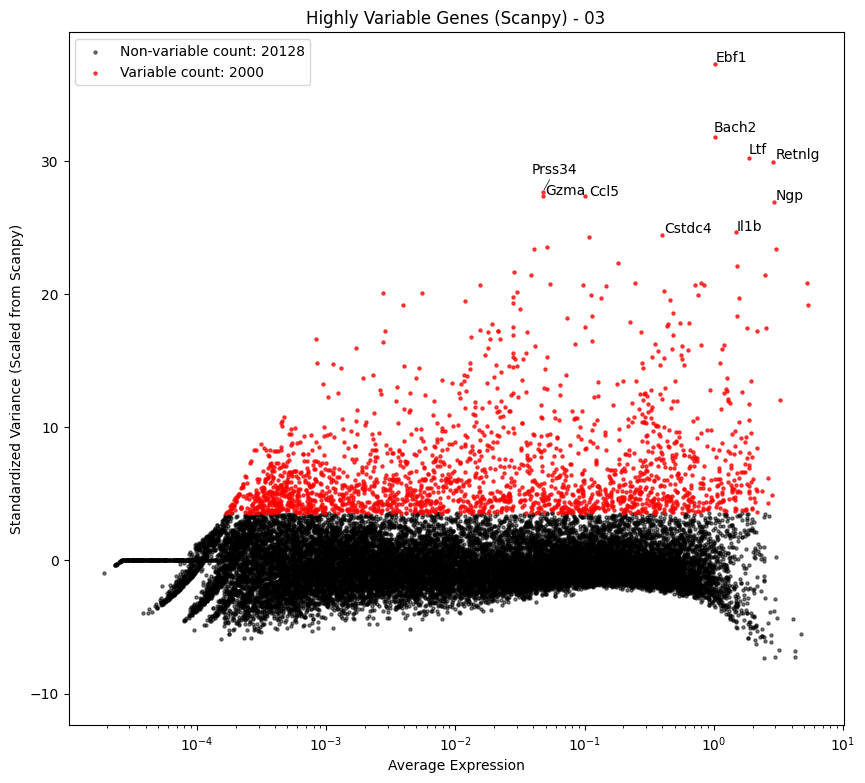

In [16]:
# Plotting HVG
means = adata_plot.var["means"]
var = adata_plot.var["variances_norm"]
hvg = adata_plot.var["highly_variable"]

var_transformed = (var - 1) * 10

plt.figure(figsize=(10, 9))

# Non-variable genes
plt.scatter(means[~hvg], var_transformed[~hvg], s=5, color="black", alpha=0.5)

# HVGs
plt.scatter(means[hvg], var_transformed[hvg], s=5, color="red", alpha=0.7)

plt.xscale("log")
plt.xlabel("Average Expression")
plt.ylabel("Standardized Variance (Scaled from Scanpy)")

plt.legend([
    f"Non-variable count: {(~hvg).sum()}",
    f"Variable count: {hvg.sum()}"
])

plt.title("Highly Variable Genes (Scanpy) - 03")

top_genes = adata_plot.var[adata_plot.var["highly_variable"]] \
    .sort_values("variances_norm", ascending=False) \
    .head(10)

texts = []

for gene in top_genes.index:
    x = adata_plot.var.loc[gene, "means"]
    y = var_transformed.loc[gene]

    texts.append(plt.text(x, y, gene, fontsize=10))

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
)

plt.savefig("scanpy_03/hvg_scanpy_03.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# HVG
scanpy_hvg = adata.var_names[adata.var["highly_variable"]]
# simple list
pd.Series(list(scanpy_hvg)).to_csv("scanpy_hvg_03.csv", index=False, header=False)


In [18]:
# Scaling
adata = adata[:, adata.var["highly_variable"]].copy()

timed("Scaling", lambda: sc.pp.scale(
    adata,
    zero_center=True,
    max_value=10
))

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Scaling: 1.01 sec


In [19]:
# PCA
timed("PCA", lambda: sc.tl.pca(
    adata,
    n_comps=50,
    svd_solver="arpack",
    random_state=42
))

PCA: 6.63 sec


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loadings = adata.varm["PCs"]

# Select PC1 [0] or PC2 [1]
pc = loadings[:, 0]
genes = adata.var_names

df = pd.DataFrame({
    "gene": genes,
    "loading": pc
})

df["abs_loading"] = df["loading"].abs()

df_plot = df.sort_values("abs_loading", ascending=False).head(20)

df_plot = df_plot.sort_values("loading")

# Plot
plt.figure(figsize=(6,5))

plt.scatter(
    df_plot["loading"],
    df_plot["gene"],
    s=60   # dot size
)

plt.axvline(0, linestyle="--")
plt.xlabel("Loading")
plt.title("PC1 Loadings")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig("scanpy_03/pc1_loadings_dotplot_03.png", dpi=300)
plt.close()

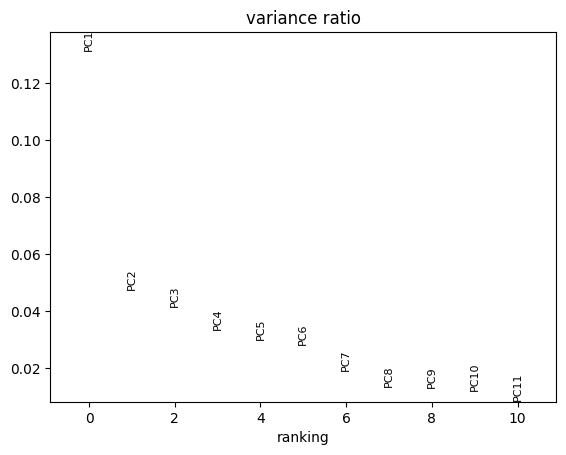

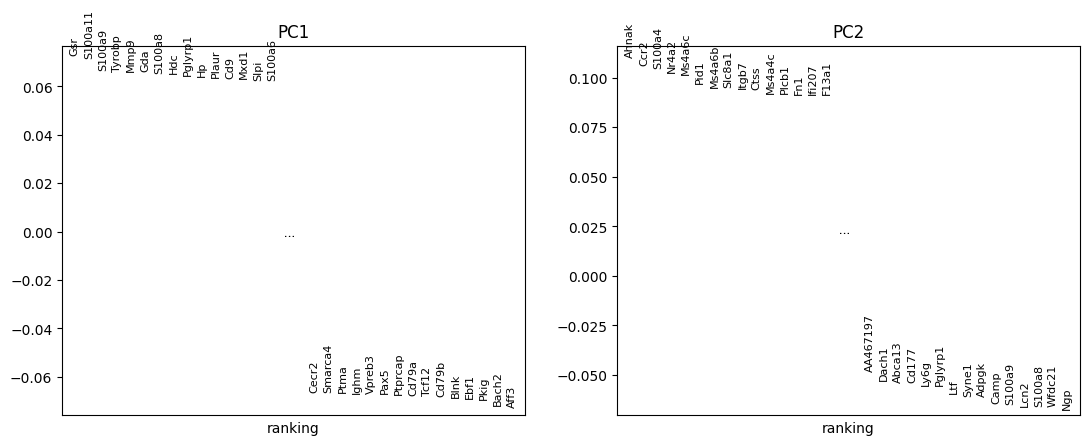

In [22]:
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=10)
sc.pl.pca_loadings(adata, components="1,2")



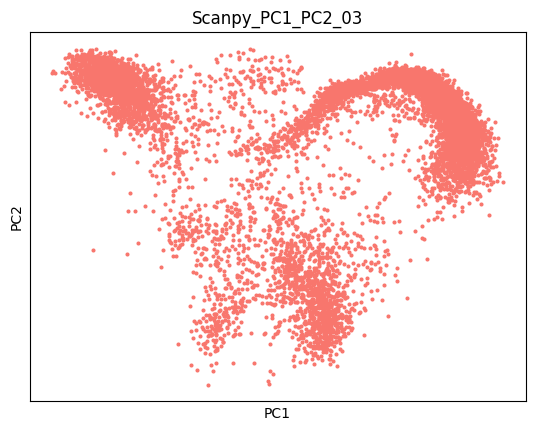

In [24]:
# Flip to match Seurat
adata.obsm["X_pca"][:, 0] *= -1
adata.obsm["X_pca"][:, 1] *= -1

sc.pl.pca(
    adata,
    color=None,
    size=15,
    title="Scanpy_PC1_PC2_03",
    show=False
)

ax = plt.gca()

ax.collections[0].set_color("#F8766D")

# Match aspect
#ax.set_aspect('equal', adjustable='datalim')
#ax.margins(0.05)

plt.savefig("figures/pca_pc1_pc2_scanpy_03.png", dpi=300)
plt.show()

In [25]:
pca_embeddings = timed(
    "Embedding extraction",
    lambda: adata.obsm["X_pca"][:, :2]
)

pd.DataFrame(
    pca_embeddings,
    columns=["PC1", "PC2"]
).to_csv("scanpy_03/scanpy_pca_embeddings_03.csv", index=False)

Embedding extraction: 0.00 sec


In [26]:
adata.uns["pca"]["variance_ratio"].sum()

np.float64(0.47579043491835976)

In [27]:
var_explained = timed(
    "Variance explained",
    lambda: adata.uns["pca"]["variance"] / adata.uns["pca"]["variance"].sum()
)

variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(var_explained))],
    "Variance": var_explained
})

variance_df.to_csv("scanpy_03/scanpy_variance_explained_03.csv", index=False)

Variance explained: 0.00 sec


In [28]:
loadings = timed(
    "Loadings extraction",
    lambda: adata.varm["PCs"]
)

Loadings extraction: 0.00 sec


In [29]:
def compute_top_genes():
    pc1_vals = np.abs(loadings[:, 0])
    pc2_vals = np.abs(loadings[:, 1])

    top_pc1_idx = np.argsort(pc1_vals)[::-1][:10]
    top_pc2_idx = np.argsort(pc2_vals)[::-1][:10]

    pc1_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc1_idx],
        "Loading": pc1_vals[top_pc1_idx]
    })

    pc2_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc2_idx],
        "Loading": pc2_vals[top_pc2_idx]
    })

    pc1_df.to_csv("scanpy_03/scanpy_pc1_genes_03.csv", index=False)
    pc2_df.to_csv("scanpy_03/scanpy_pc2_genes_03.csv", index=False)

timed("Top gene extraction", compute_top_genes)

Top gene extraction: 0.01 sec


In [30]:
timed("Neighbors", lambda: sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=10
))

Neighbors: 93.43 sec


In [31]:
timed("Clustering", lambda: sc.tl.leiden(
    adata,
    resolution=0.5
))

/tmp/ipykernel_14831/1214221455.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  timed("Clustering", lambda: sc.tl.leiden(


Clustering: 6.79 sec


In [32]:
timed("UMAP", lambda: sc.tl.umap(adata))

UMAP: 21.44 sec


In [33]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="UMAP",
    frameon=True,
    show=False
)

fig = plt.gcf()
ax = fig.axes[0]

ax.invert_xaxis()

# Add labels
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")

plt.savefig("scanpy_03/umap_scanpy_03", dpi=300, bbox_inches="tight")
plt.close()

In [34]:
pd.DataFrame(runtime_log, columns=["Step", "Time_sec"])\
  .to_csv("scanpy_03/runtime_log_scanpy_03.csv", index=False)